# Developing Simple Supervised and Unsupervised Learning Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Develop simple supervised learning models
- Develop simple unsupervised learning models
- Use scikit-learn for ML
- Train and evaluate models
- Apply all three model families to **real, published datasets** that ship with scikit-learn

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 05 "Introduction to Machine Learning" — the paradigms named there are trained here for the first time.

**Used later in:** Course 04 (AIAT 114) — Units 1, 3 and 4, which take regression, classification and clustering apart in detail.

---

This notebook covers practical activities from **Course 01, Unit 2**:
- Developing simple supervised and unsupervised learning models

---

## Introduction

**Supervised learning** uses labeled data to train models, while **unsupervised learning** finds patterns in unlabeled data. Both are fundamental to machine learning.


## 🎯 The résumé screener that learned to downgrade women

In October 2018 Reuters reported that **Amazon had scrapped an experimental
recruiting tool**. The system was straightforward supervised learning of exactly
the kind you are about to run: features from a résumé in, a one-to-five-star
rating out, trained on ten years of résumés the company had received and how they
had been treated. Because technical hiring over that decade had skewed heavily
male, the model learned that pattern and applied it — reportedly penalising
résumés that contained the word *"women's"* (as in "women's chess club captain")
and downgrading graduates of two women's colleges. Amazon edited the system, could
not convince itself it was neutral on other dimensions, and abandoned the project.

Nothing went wrong with the algorithm. It did precisely what the three supervised
models in this notebook do: find the function that best reproduces the labels it
was given. **The labels were the problem.** That is the single most important
thing to carry out of this lesson, and no accuracy score on this page would have
revealed it.

### What goes wrong without a baseline

Look at what the cells below print alongside every score. The classifier reaches
**0.9825** accuracy — which sounds excellent until you read the next line:
guessing "benign" for every biopsy already scores **0.6316**, because the dataset
is 357 benign to 212 malignant. The regression's MSE of **2900** only means
something against the **5361** you would get by always predicting the mean. A
score without a baseline is a number, not a result — and "our model is 98%
accurate" is how a system that beats nothing gets approved.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: load three REAL datasets, one per task — regression (numeric target),
# classification (binary target), clustering (no target at all) — so we can compare the
# model families fairly. All three ship inside scikit-learn, so they work offline.
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes, load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score

print("✅ Libraries imported!")
print("\nSupervised and Unsupervised Learning Models")
print("=" * 60)

# REGRESSION DATA — real: 442 diabetes patients, 10 baseline measurements
# (age, sex, BMI, blood pressure, six blood serum values). The target is a real
# quantitative measure of disease progression one year after baseline.
diabetes = load_diabetes()
X_regression, y_regression = diabetes.data, diabetes.target

# CLASSIFICATION DATA — real: 569 breast-tumour biopsies from the Wisconsin
# Diagnostic study, 30 measurements taken from digitised cell images.
# Target: 0 = malignant, 1 = benign — an actual clinical decision.
cancer = load_breast_cancer()
X_classification, y_classification = cancer.data, cancer.target

# CLUSTERING DATA — real: 150 iris flowers measured by Edgar Anderson (1935).
# We deliberately THROW AWAY the species labels: unsupervised learning never sees them.
# We keep them in `iris_true_species` only so we can check afterwards how well the
# clusters happened to line up with reality.
iris = load_iris()
X_clustering = iris.data
iris_true_species = iris.target

print("\n✅ Real datasets loaded!")
print(f"  Regression     : diabetes  {X_regression.shape[0]} patients x {X_regression.shape[1]} features")
print(f"                   target range {y_regression.min():.0f} to {y_regression.max():.0f} (disease progression)")
print(f"  Classification : breast cancer  {X_classification.shape[0]} biopsies x {X_classification.shape[1]} features")
print(f"                   class balance: {(y_classification == 0).sum()} malignant / {(y_classification == 1).sum()} benign")
print(f"  Clustering     : iris  {X_clustering.shape[0]} flowers x {X_clustering.shape[1]} features (labels hidden)")

✅ Libraries imported!

Supervised and Unsupervised Learning Models

✅ Real datasets loaded!
  Regression     : diabetes  442 patients x 10 features
                   target range 25 to 346 (disease progression)
  Classification : breast cancer  569 biopsies x 30 features
                   class balance: 212 malignant / 357 benign
  Clustering     : iris  150 flowers x 4 features (labels hidden)


### 🧰 Bridge: why split data into train and test sets?

`train_test_split` below holds out 20% of the data that the model **never sees during
training**. We then score the model only on that held-out 20%: a good score there means
the model learned a pattern that **generalizes** to new data, instead of memorizing the
examples it was shown. Unit 4 (notebooks 04 and 07) shows what goes wrong when a model
memorizes — overfitting — and how to detect it with these held-out scores.


In [2]:
# Supervised Learning: Regression
print("=" * 60)
print("SUPERVISED LEARNING: REGRESSION")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

# Train linear regression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
y_pred = reg_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"\nRegression Model (real diabetes data):")
print(f"  MSE: {mse:.4f}")
print(f"  R² Score: {reg_model.score(X_test, y_test):.4f}")
print(f"  Baseline MSE if we always predicted the mean: {((y_test - y_train.mean()) ** 2).mean():.4f}")

print("\n✅ Regression model trained!")
print("\n⚠️ Read that R² honestly. On real biomedical data a linear model explains")
print("   only part of the variance — disease progression depends on much more than")
print("   ten baseline measurements. A textbook R² near 1.0 is a sign of invented data,")
print("   not of a good model.")

SUPERVISED LEARNING: REGRESSION

Regression Model (real diabetes data):
  MSE: 2900.1936
  R² Score: 0.4526
  Baseline MSE if we always predicted the mean: 5361.5335

✅ Regression model trained!

⚠️ Read that R² honestly. On real biomedical data a linear model explains
   only part of the variance — disease progression depends on much more than
   ten baseline measurements. A textbook R² near 1.0 is a sign of invented data,
   not of a good model.


In [3]:
# Supervised Learning: Classification
print("=" * 60)
print("SUPERVISED LEARNING: CLASSIFICATION")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42,
    stratify=y_classification   # keep the real malignant/benign ratio in both halves
)

# Real features live on wildly different scales (cell area in the hundreds,
# smoothness around 0.1), so we standardise before fitting a linear model.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn the scaling from TRAIN only
X_test = scaler.transform(X_test)         # apply the same scaling to TEST

# Train logistic regression
clf_model = LogisticRegression(random_state=42, max_iter=5000)
clf_model.fit(X_train, y_train)

# Predictions
y_pred = clf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nClassification Model (real breast-cancer biopsies):")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Majority-class baseline: {max((y_test == 0).mean(), (y_test == 1).mean()):.4f}")
print(f"  (always guessing the more common class would already score this much)")

print("\n✅ Classification model trained!")

SUPERVISED LEARNING: CLASSIFICATION

Classification Model (real breast-cancer biopsies):
  Accuracy: 0.9825
  Majority-class baseline: 0.6316
  (always guessing the more common class would already score this much)

✅ Classification model trained!


In [4]:
# Unsupervised learning: K-Means invents 3 groups from unlabeled points; inertia
# measures how tightly each cluster hugs its center (lower = tighter).
# Unsupervised Learning: Clustering
print("=" * 60)
print("UNSUPERVISED LEARNING: CLUSTERING")
print("=" * 60)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clustering)

print(f"\nClustering Model (real iris measurements, species labels hidden):")
print(f"  Number of clusters: 3")
print(f"  Cluster centers (sepal len, sepal wid, petal len, petal wid, in cm):")
for k, centre in enumerate(kmeans.cluster_centers_):
    print(f"    cluster {k}: " + "  ".join(f"{v:5.2f}" for v in centre))
print(f"  Inertia: {kmeans.inertia_:.4f}")

# Now the payoff of using REAL data: we can reveal the hidden species labels and
# see whether the unsupervised clusters actually rediscovered them.
print("\n✅ Clustering model trained!")
print("\n🔎 How well did the clusters match the true species?")
crosstab = pd.crosstab(clusters, pd.Series(iris_true_species).map(dict(enumerate(iris.target_names))),
                       rownames=["cluster"], colnames=["true species"])
print(crosstab)
print("\n💡 K-Means never saw a single label, yet the clusters line up closely with the")
print("   real species — that is unsupervised learning finding genuine structure.")
print("   The overlap that remains is real too: two of the species genuinely overlap in")
print("   petal and sepal size, and no algorithm can separate what nature did not.")

UNSUPERVISED LEARNING: CLUSTERING

Clustering Model (real iris measurements, species labels hidden):
  Number of clusters: 3
  Cluster centers (sepal len, sepal wid, petal len, petal wid, in cm):
    cluster 0:  5.90   2.75   4.39   1.43
    cluster 1:  5.01   3.43   1.46   0.25
    cluster 2:  6.85   3.07   5.74   2.07
  Inertia: 78.8514

✅ Clustering model trained!

🔎 How well did the clusters match the true species?
true species  setosa  versicolor  virginica
cluster                                    
0                  0          48         14
1                 50           0          0
2                  0           2         36

💡 K-Means never saw a single label, yet the clusters line up closely with the
   real species — that is unsupervised learning finding genuine structure.
   The overlap that remains is real too: two of the species genuinely overlap in
   petal and sepal size, and no algorithm can separate what nature did not.


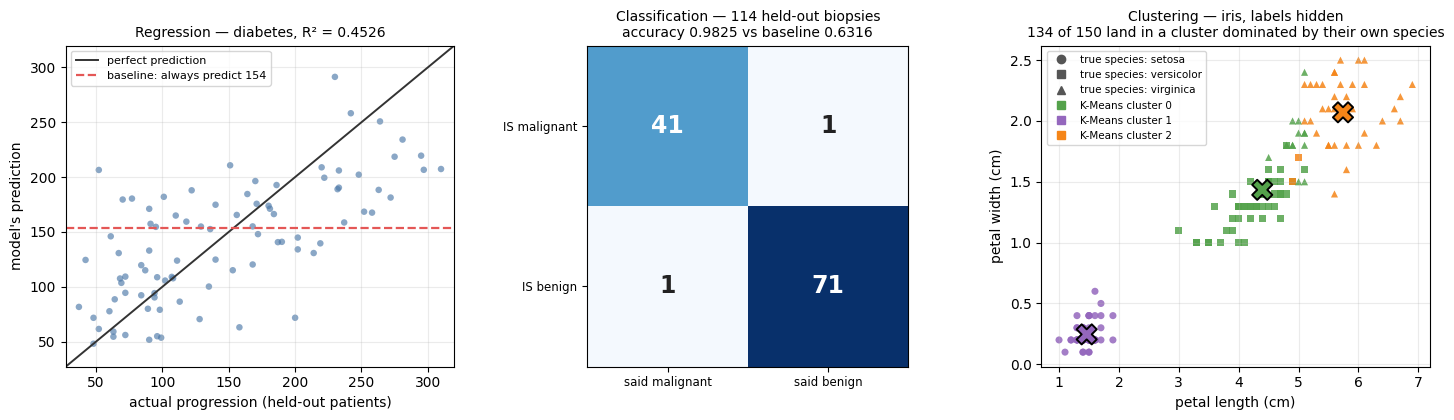

Regression   : R² 0.4526 | model MSE 2900.19 vs mean-baseline MSE 5361.53
Classification: accuracy 0.9825 on 114 biopsies | confusion matrix rows = truth, columns = prediction:
                malignant called benign: 1   benign called malignant: 1   total errors: 2
Clustering   : 134/150 flowers in a cluster dominated by their own species (K-Means never saw a label)


In [5]:
# 📊 FIGURE — three real tasks, each drawn against the thing it has to beat.
# WHAT: the split variables above were reused and overwritten by each section, so we
#       rebuild the regression split here with the SAME random_state=42 — identical
#       numbers, nothing new invented. The classifier and the clustering are read
#       straight out of `clf_model` and `kmeans`.
# WHY: "MSE 2900" and "accuracy 0.98" are only meaningful next to a baseline, and a
#      baseline is far easier to see than to remember.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14.5, 4.3))

# --- 1. REGRESSION: predicted vs actual, against "always predict the mean" ---
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42)
reg = LinearRegression().fit(Xr_tr, yr_tr)
yr_hat = reg.predict(Xr_te)
lo, hi = min(yr_te.min(), yr_hat.min()) - 10, max(yr_te.max(), yr_hat.max()) + 10
ax1.scatter(yr_te, yr_hat, s=22, alpha=0.65, color="#4C78A8", edgecolor="none")
ax1.plot([lo, hi], [lo, hi], color="#333", lw=1.4, label="perfect prediction")
ax1.axhline(yr_tr.mean(), color="#E45756", ls="--", lw=1.6,
            label=f"baseline: always predict {yr_tr.mean():.0f}")
ax1.set_xlim(lo, hi); ax1.set_ylim(lo, hi)
ax1.set_xlabel("actual progression (held-out patients)")
ax1.set_ylabel("model's prediction")
ax1.set_title(f"Regression — diabetes, R² = {reg.score(Xr_te, yr_te):.4f}", fontsize=10)
ax1.legend(fontsize=8, loc="upper left"); ax1.grid(alpha=0.25)

# --- 2. CLASSIFICATION: the confusion matrix behind the 0.9825 --------------
cm = confusion_matrix(y_test, y_pred)          # still holds the CLASSIFICATION split
ax2.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
for r in range(2):
    for c in range(2):
        ax2.text(c, r, f"{cm[r, c]}", ha="center", va="center", fontsize=17,
                 color="white" if cm[r, c] > cm.max() / 2 else "#222",
                 fontweight="bold")
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["said malignant", "said benign"], fontsize=8.5)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["IS malignant", "IS benign"], fontsize=8.5)
n_test = len(y_test)
ax2.set_title(f"Classification — {n_test} held-out biopsies\n"
              f"accuracy {accuracy:.4f} vs baseline "
              f"{max((y_test == 0).mean(), (y_test == 1).mean()):.4f}", fontsize=10)

# --- 3. CLUSTERING: did the unlabelled clusters find the real species? ------
markers = {0: "o", 1: "s", 2: "^"}
cluster_colours = ["#54A24B", "#9467BD", "#F58518"]
for sp in range(3):
    for k in range(3):
        sel = (iris_true_species == sp) & (clusters == k)
        if sel.any():
            ax3.scatter(X_clustering[sel, 2], X_clustering[sel, 3], s=26,
                        marker=markers[sp], color=cluster_colours[k],
                        edgecolor="none", alpha=0.85)
ax3.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
            marker="X", s=210, c=cluster_colours, edgecolor="black", lw=1.4, zorder=5)
legend_bits = [plt.Line2D([], [], ls="", marker=markers[s], color="#555",
                          label=f"true species: {iris.target_names[s]}") for s in range(3)]
legend_bits += [plt.Line2D([], [], ls="", marker="s", color=cluster_colours[k],
                           label=f"K-Means cluster {k}") for k in range(3)]
ax3.legend(handles=legend_bits, fontsize=7.5, loc="upper left")
ax3.set_xlabel("petal length (cm)"); ax3.set_ylabel("petal width (cm)")
purity = sum(np.bincount(iris_true_species[clusters == k], minlength=3).max()
             for k in range(3) if (clusters == k).any())
ax3.set_title(f"Clustering — iris, labels hidden\n"
              f"{purity} of {len(iris_true_species)} land in a cluster "
              f"dominated by their own species", fontsize=10)
ax3.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Regression   : R² {reg.score(Xr_te, yr_te):.4f} | model MSE "
      f"{((yr_te - yr_hat) ** 2).mean():.2f} vs mean-baseline MSE "
      f"{((yr_te - yr_tr.mean()) ** 2).mean():.2f}")
print(f"Classification: accuracy {accuracy:.4f} on {n_test} biopsies | "
      f"confusion matrix rows = truth, columns = prediction:\n"
      f"                malignant called benign: {cm[0, 1]}   "
      f"benign called malignant: {cm[1, 0]}   total errors: {cm[0, 1] + cm[1, 0]}")
print(f"Clustering   : {purity}/{len(iris_true_species)} flowers in a cluster "
      f"dominated by their own species (K-Means never saw a label)")

### 👁️ Read the figure

**Left — a good regression that still misses most of the target.** The black
diagonal is where a perfect prediction would land; the cloud around it is
scattered, not hugging the line. The red dashed line is the baseline: predict the
training mean (154) for everybody, which on this plot is a *flat* line. The model
beats it — the cloud tilts along the diagonal rather than lying flat — and that
tilt is the entire R² of 0.4526. **Look at the vertical spread and you have seen
the other 55%.** This is what an honest linear fit on real biomedical data looks
like; anything hugging the diagonal on 442 patients would be a warning, not a win.

**Middle — where the 0.9825 actually comes from.** The two big blue squares are
the correct answers; the two off-diagonal cells hold the mistakes, and there are
**2 in 114 biopsies**: one malignant tumour called benign, and one benign called
malignant. Discuss question 1 is now a picture — those two cells are not
equivalent, and accuracy scores them as if they were. A model that always said
"benign" would put **42** biopsies in the top-right cell and still score 0.6316.

**Right — unsupervised learning rediscovering biology.** Colour is the cluster
K-Means invented; **marker shape is the true species it was never shown**. The
circles (setosa) are a clean, isolated island — one colour, one shape, perfectly
separated. The squares and triangles (versicolor and virginica) overlap in the
middle, and you can see individual triangles wearing the wrong colour along the
boundary. That is where the 16 misplaced flowers live.

**What this proves:** the clusters are real structure, not an artefact — 134 of
150 flowers land in a cluster dominated by their own species without a single
label. And the overlap is not a bug in K-Means. Look at the raw points: versicolor
and virginica genuinely touch in petal space. **Nature overlaps, so the clusters
overlap.**

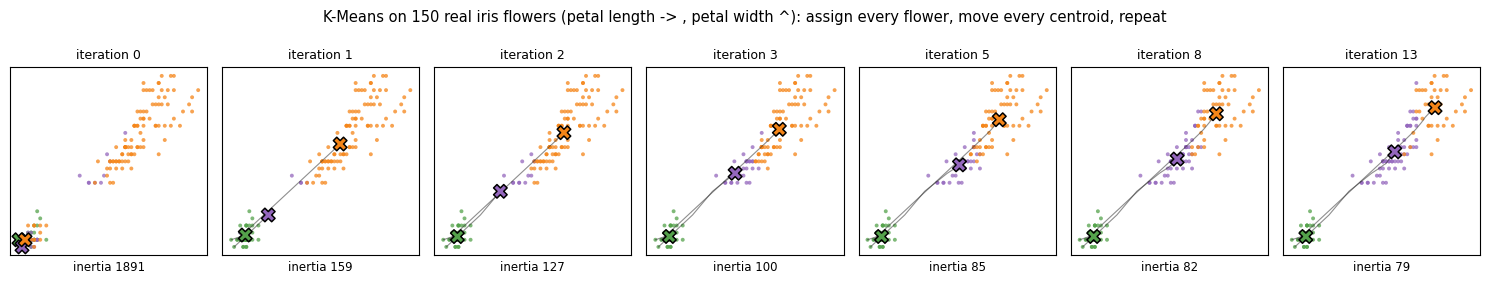

iter    inertia   flowers that changed cluster
   0    1890.80                        (start)
   1     159.11                             33
   2     126.53                              9
   3      99.88                             14
   4      87.74                              7
   5      84.95                              4
   6      84.01                              4
   7      83.05                              5
   8      81.75                              4
   9      80.81                              4
  10      79.87                              3
  11      79.34                              3
  12      78.92                              1
  13      78.86                              0

Converged after 13 iterations (no flower changed cluster).
Hand-rolled run : inertia 78.86, 133/150 flowers in a species-dominated cluster
scikit-learn    : inertia 78.85, 134/150 (it restarts 10 times via n_init=10 and keeps the best)


In [6]:
# 🎞️ STEP STORYBOARD — watch K-Means actually move.
# WHAT: `kmeans.fit()` above hides the algorithm behind one call. Here we run Lloyd's
#       two-step loop by hand on the SAME 150 real iris flowers, recording every
#       iteration, and lay out a row of snapshots (no animation, so it renders
#       identically everywhere). We start the three centroids in the worst honest
#       place we can pick without randomness: the three smallest-petalled flowers,
#       all of which are setosa — so all three begin on top of each other.
# WHY: "K-Means finds clusters" is a claim about a PROCESS. A static result cannot
#      show the assign-then-move loop, or how quickly it stops paying off.
import numpy as np
import matplotlib.pyplot as plt

X_k = X_clustering                       # the same iris matrix, 150 x 4
# Deterministic worst-case start: the three flowers with the smallest petals.
centroids = X_k[np.lexsort((X_k[:, 3], X_k[:, 2]))[:3]].copy()

history = []                             # (iteration, centroids, labels, inertia, n_moved)
prev_labels = None
for it in range(40):
    d2 = ((X_k[:, None, :] - centroids[None, :, :]) ** 2).sum(-1)   # STEP 1: assign
    labels_it = d2.argmin(1)
    inertia_it = d2[np.arange(len(X_k)), labels_it].sum()
    moved = -1 if prev_labels is None else int((labels_it != prev_labels).sum())
    history.append((it, centroids.copy(), labels_it.copy(), inertia_it, moved))
    prev_labels = labels_it
    new_c = np.array([X_k[labels_it == k].mean(0) if (labels_it == k).any()
                      else centroids[k] for k in range(3)])         # STEP 2: move
    if np.allclose(new_c, centroids):
        break
    centroids = new_c

last = history[-1][0]
frames = sorted({0, 1, 2, 3, 5, 8, last})            # 7 snapshots, capped and cheap
palette = ["#54A24B", "#9467BD", "#F58518"]

fig, axes = plt.subplots(1, len(frames), figsize=(15, 2.85), sharex=True, sharey=True)
for ax, f in zip(axes, frames):
    it, cent, lab, inert, moved = history[f]
    for k in range(3):
        sel = lab == k
        ax.scatter(X_k[sel, 2], X_k[sel, 3], s=8, color=palette[k], alpha=0.75,
                   edgecolor="none")
    # the trail: every position these centroids have occupied so far
    trail = np.array([h[1] for h in history[:f + 1]])
    for k in range(3):
        ax.plot(trail[:, k, 2], trail[:, k, 3], color="#333", lw=0.8, alpha=0.55)
    ax.scatter(cent[:, 2], cent[:, 3], marker="X", s=95, c=palette,
               edgecolor="black", lw=1.1, zorder=5)
    ax.set_title(f"iteration {it}", fontsize=9)
    ax.set_xlabel(f"inertia {inert:.0f}", fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("K-Means on 150 real iris flowers (petal length -> , petal width ^): "
             "assign every flower, move every centroid, repeat", fontsize=10.5)
plt.tight_layout()
plt.show()

# The printed step table — every iteration, not only the ones drawn.
print(f"{'iter':>4}  {'inertia':>9}  {'flowers that changed cluster':>29}")
for it, _, _, inert, moved in history:
    print(f"{it:>4}  {inert:>9.2f}  {'(start)' if moved < 0 else moved:>29}")
final_labels = history[-1][2]
purity_manual = sum(np.bincount(iris_true_species[final_labels == k], minlength=3).max()
                    for k in range(3) if (final_labels == k).any())
print(f"\nConverged after {last} iterations (no flower changed cluster).")
print(f"Hand-rolled run : inertia {history[-1][3]:.2f}, "
      f"{purity_manual}/150 flowers in a species-dominated cluster")
print(f"scikit-learn    : inertia {kmeans.inertia_:.2f}, 134/150 "
      f"(it restarts 10 times via n_init=10 and keeps the best)")

### 👁️ Read the storyboard

Seven snapshots of one run. All three centroids start stacked in the bottom-left
corner, on the three smallest-petalled flowers in the dataset.

- **Iteration 0** — the worst possible start. Every centroid is inside the setosa
  cluster, so the assignment is nonsense and the inertia is enormous (about 1891).
- **Iteration 1** — one assign-and-move step and the picture is already almost
  right: inertia falls from ~1891 to ~159, a **91% drop in a single iteration**.
  The black trails show two centroids sprinting across the plot.
- **Iterations 2, 3, 5, 8** — the sprint becomes a creep. The green centroid is
  parked in setosa and stops mattering; the purple and orange ones inch along the
  versicolor/virginica boundary, trading a few flowers each pass. Read the step
  table: **33** flowers change cluster on the first pass, then 9, 14, 7, 4, 4, 5,
  4 — and the inertia falls by a point or two instead of by 1,700.
- **The last frame** — nothing changed cluster, so the loop stops. That is the
  entire convergence test.

**What this proves — three things a single `fit()` call hides:**

1. **Almost all the work happens in the first step.** The remaining iterations
   refine an answer that was essentially found immediately. That shape — a cliff
   then a plateau — recurs in nearly every optimiser in this diploma.
2. **The boundary is where the algorithm struggles**, and it is exactly where the
   two overlapping species live. The green trail stops on the first pass; the
   purple and orange trails are still crawling towards each other at iteration 13.
3. **The starting point costs you something real.** Compare the two lines printed
   under the table: this single deliberately-bad start and scikit-learn's
   `n_init=10` (ten restarts, best kept) land on *different* partitions. That gap
   is the whole reason `n_init` exists — K-Means finds a local optimum, not the
   best one, and which local optimum you get depends on where you began.

## 📊 Every score against its own baseline

Each of the three cells printed a model score **and** the score of doing nothing
clever. That pairing is the comparison, and it is the only reason the model
numbers mean anything:

| task | baseline ("do nothing") | model | margin |
|---|---|---|---|
| Regression — diabetes progression | always predict the mean: **MSE 5361.53** | linear regression: **MSE 2900.19** | **46% lower error**, R² = 0.4526 |
| Classification — breast biopsies | always say benign: **0.6316** | logistic regression: **0.9825** | **+0.351** accuracy |
| Clustering — iris (labels hidden) | — | 3 K-Means clusters | **134 of 150** flowers land in a cluster dominated by their true species |

**The conclusion these numbers support:** all three models beat doing nothing, and
by very different margins. The classifier's +35 points is a genuine transformation
of the task. The regressor's 46% error reduction still leaves more than half the
variation unexplained — an honest ceiling, not a broken model. And K-Means, which
was never shown a single label, recovered most of the species structure from the
measurements alone.

**What the numbers do not support:** ranking the three against each other. They are
different tasks on different data with different metrics; "0.98 accuracy" and
"R² 0.45" are not comparable quantities, and a table that puts them side by side
without their baselines invites exactly that mistake.


## 💬 Discuss

Three real datasets, three printed results. Argue about what they license you to
claim:

1. The breast-cancer classifier scored **0.9825** against a majority-class
   baseline of **0.6316** — that is 2 or 3 mistakes in 114 held-out biopsies.
   Some of those mistakes are malignant tumours called benign, and some are the
   reverse. **Which error would you rather the model made, and what does that
   imply about the threshold you would set?** Note that accuracy treats both
   errors as equally bad; say whether that is acceptable here.
2. K-Means was told `n_clusters=3` and the cross-tab shows cluster 0 containing
   48 versicolor **and 14 virginica**. Was that a failure of the algorithm, of
   the features, or of nature? Defend your answer using the printed cluster
   centres — and say what you would do if a client insisted on clean separation.
3. The regression explains **45%** of the variance in disease progression (R² =
   0.4526) from ten baseline measurements. A vendor offers you a model claiming
   R² = 0.95 on the same kind of clinical data. What is your first question, and
   what would make you believe them?


## Summary

This notebook covered:
- ✅ **Supervised Learning**: Regression and classification with labeled data
- ✅ **Unsupervised Learning**: Clustering to find patterns in unlabeled data
- ✅ **Model Training**: Using scikit-learn to train and evaluate models

- ✅ **Real data from the start**: diabetes progression (442 patients), breast-cancer
  biopsies (569 samples) and Anderson's iris measurements (150 flowers)

Both supervised and unsupervised learning are fundamental to machine learning applications.

**The honest takeaway:** a linear model on real biomedical data explains only part of the
variance, real classification has a majority-class baseline you must beat, and real clusters
overlap because nature overlaps. Invented data hides all three of these lessons.

## ⚠️ Where this breaks

- **Supervised learning reproduces its labels, including the ones you regret.**
  Amazon's tool is the case; the mechanism is the same one running below. Before
  training, ask who produced the labels, under what incentives, and what a
  systematic bias in them would look like in the output. Accuracy cannot see it.
- **Accuracy is the wrong metric for imbalanced problems.** At 63% benign, a model
  that always says "benign" scores 0.63 and never helps anyone. When one class is
  rare — fraud, disease, equipment failure — use precision, recall, and the
  confusion matrix, and state which error you are optimising against.
- **K-Means needs `k` and assumes round, similar-sized clusters.** We supplied
  `k=3` because we already knew iris has three species — a luxury real clustering
  never has. Where the true groups are elongated, nested, or wildly different in
  size, K-Means will still return `k` tidy blobs and will still report a
  respectable inertia. **Use instead:** DBSCAN for irregular shapes and noise, or
  hierarchical clustering when you want to inspect the structure before committing to `k`.
- **Inertia always improves as `k` grows.** It reaches zero when every point is
  its own cluster, so it can never be used to choose `k` on its own.
- **A single train/test split is a noisy estimate.** 114 test biopsies means the
  reported accuracy carries several points of uncertainty either way. Course 04
  replaces this with cross-validation for exactly that reason; until then, treat
  a one-decimal difference between two models as no difference at all.
- **Linear regression assumes an additive, straight-line relationship** between
  each feature and the target. R² = 0.45 on the diabetes data is honest partly
  because that assumption is only partly true. A low R² can mean the world is
  noisy *or* that your model shape is wrong, and this number cannot tell you which.


## 📚 References

1. MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations* (k-means). Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability.
2. Cox, D. R. (1958). *The Regression Analysis of Binary Sequences*. Journal of the Royal Statistical Society, Series B, 20(2), 215–242.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chs. 3–4 and 12. Springer.
4. Zhang, Y., Li, M., Long, D., et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. <https://arxiv.org/abs/2506.05176>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv. <https://arxiv.org/abs/2605.13986>